# Introduction and Workshop Scope : "RDF Dump"

The workshop offers a playground notebook to create or to explore RDF dumps. If you are unfamiliar with linked data, we recommend reading the [corresponding lesson of "Programming Historian"](https://doi.org/10.46430/phen0068).

This workshop offers a brief practical introduction of how to browse RDF dumps or how to build RDF graphs for database exploration and open research purposes. Basic know-how about querying or building LOD data, basic analysis for exploration, here in the Python language, and editorial issues should be in the hands of trainees.

This workshop is split in five parts, plus further reading:
1. A first part introduces Python packages to be used in Jupyter notebooks. Some ressource gives further tutorials for working on your local machine.
2. A second part provides Python recipies for browsing dumps from wikidata and Factgrid wikibase, in order to collect data from the graph.
3. A third part helps with building RDF graphs in Python using `rdflib`.
4. A fourth part shows how to use of SPARQL queries and how to display results on maps or timelines, leading to first concrete examples.
5. A last part aims at producing a scientific publication within the Journal of Digital History's editorial technology stack.

# General framework: from data to scientific publication

## From data collection

Data in the scope of the workshop are linked open data available on FactGrid, a database for historical research. It is an international collaborative platform using Wikimedia's ground-breaking wikibase software, run at the Gotha Research Centre and hosted at the Thuringian State and University Library ThULB in Jena (see https://blog.factgrid.de/welcome).

```{iframe} https://blog.factgrid.de/
:align: center
:label: factgrid-blog
Factgrid blog [https://blog.factgrid.de/](https://blog.factgrid.de/)
```
## Data model under scope

These data follow a general modelling framework for RDF triplets with domains and ranges that can take many value types (statements, xsd date, simple values etc.), like in a wikidata dump. Predicates also follow the wikidata schema with differentiating paths regarding the type of property under scope (see for exemple, figure below).
```{figure} ./img/Rdf_mapping-vector.svg.png
:align: center
:label: Wikibase Data model 
Wikidata model, source : [https://www.mediawiki.org/wiki/Wikibase/Indexing/RDF_Dump_Format](https://www.mediawiki.org/wiki/Wikibase/Indexing/RDF_Dump_Format)
```

## Computational notebook framework: multi-purpose from exploration to scientific publication, through workshop training

Within this workshop, you will be invited to play with your own computational Jupyter notebook online. However, the more curious or skilled may follow our guidelines (in French) to install local Jupyter instances for running the workshop's computational notebooks directly on your own machine: [Ressources to install Jupyter Notebook framework on your local machine](https://mise-en-pratique-5e5223.gricad-pages.univ-grenoble-alpes.fr/jupyter.html).

The Jupyter notebook may take two different forms: one based on mystmd technology, and the traditional JSON format ipynb. If you wish to prepare a JDH article proposal with the framework proposed, you may follow these two steps:
- push your ipynb into a github repo,
- copy-paste the URL of your ipynb computational notebook on your github repo there: [View JDH](https://journalofdigitalhistory.org/en/notebook-viewer-form)

```{figure} ./img/jdh.png
:align: center
:label: jdh
Narrative, hermeneutical and code layers of the Journal of Digital History, image captured from the JDH article [https://doi.org/10.1515/JDH-2023-0018](https://doi.org/10.1515/JDH-2023-0018)
```

In [2]:
from rdflib import Graph, Namespace
# rdflib knows about quite a few popular namespaces, like W3C ontologies, schema.org etc.
#from rdflib.namespace import FOAF , XSD

# Create a Graph
g = Graph()


for prefix,ns in g.namespaces():
   print(f"""{prefix}: {ns}""")

brick: https://brickschema.org/schema/Brick#
csvw: http://www.w3.org/ns/csvw#
dc: http://purl.org/dc/elements/1.1/
dcat: http://www.w3.org/ns/dcat#
dcmitype: http://purl.org/dc/dcmitype/
dcterms: http://purl.org/dc/terms/
dcam: http://purl.org/dc/dcam/
doap: http://usefulinc.com/ns/doap#
foaf: http://xmlns.com/foaf/0.1/
geo: http://www.opengis.net/ont/geosparql#
odrl: http://www.w3.org/ns/odrl/2/
org: http://www.w3.org/ns/org#
prof: http://www.w3.org/ns/dx/prof/
prov: http://www.w3.org/ns/prov#
qb: http://purl.org/linked-data/cube#
schema: https://schema.org/
sh: http://www.w3.org/ns/shacl#
skos: http://www.w3.org/2004/02/skos/core#
sosa: http://www.w3.org/ns/sosa/
ssn: http://www.w3.org/ns/ssn/
time: http://www.w3.org/2006/time#
vann: http://purl.org/vocab/vann/
void: http://rdfs.org/ns/void#
wgs: https://www.w3.org/2003/01/geo/wgs84_pos#
owl: http://www.w3.org/2002/07/owl#
rdf: http://www.w3.org/1999/02/22-rdf-syntax-ns#
rdfs: http://www.w3.org/2000/01/rdf-schema#
xsd: http://www.w3.

# Technologies to compute: Python libraries to perform SPARQL queries

For this workshop, we chose the Python language and librairies for SPARQL queries and data visualization.

## Python packages used

- `rdflib`: working with RDF data and making SPARQL queries
- `networkx`: managing graphs
- `matplotlib`: plotting
- `plotly`: plotting as well
- `pandas`: dataframes (tabular data) in Python
- `geopandas`: an extension of `pandas` for spatial objects
- `ipysigma`: for display interactives graphs

## A "reproducible" process ?

Another package is used here to give information about how we produced the computational document. Notably, the package `session_info` gives information about system and package versions, enabling reproducibility in a controlled computational environment.

- `session_info` : retrieve software version numbers

## Install packages

In your terminal or inside your notebook, you can install these packages with `pip`:

```{code} python
!pip install session_info rdflib networkx matplotlib plotly pandas ipysigma
```

# Ontologies, namespaces or vocabularies: before browsing FactGrid wikibase dump

As stated in programming historian's lesson, building knowledge graphs require some vocabularies, like w3c standards. These namespaces are url were classes or concepts may be found within their hierarchical relations or inherited relations or equivalence (sameAs), for example. SPARQL syntax usually shorten these namespaces with associated prefixes, stated at the head of the SPARQL query.

## Namespaces and prefixes

Many widely used namespaces are predefined in `rdflib`, e.g. `FOAF`, `DublinCore`, `Schema`, or `XSD`.
Many widely used namespaces are predefined in `rdflib` package, e.g. `FOAF`, `DublinCore`, `Schema`, or `XSD`. To have a complete overview of namespaces directly available within the proposed `rdflin` framework, the following steps are useful :

However, we see no `wikibase`, nor `wikidata` or `dbpedia` namespaces. These have to be declared and bounded to specific prefixes.

## Querying Wikidata

In [12]:
# import Graph & Namespace

from rdflib import Graph, Namespace
from rdflib.namespace import NamespaceManager

# Wikidata namespace
WD = Namespace("http://www.wikidata.org/entity/")

# define graph to be crawled in
g2 = Graph()
g2.bind("wd", WD)

# define query about Mona Lisa QID
qres = g2.query(
  """
  SELECT ?o
  WHERE {
    SERVICE <https://query.wikidata.org/sparql> {
      wd:Q12418 rdfs:label ?o .
    }
  }
  LIMIT 10
  """
)

In [13]:
# print results nicely
for row in qres:
   print("wikidata identifier Q12418 <has label> : %s" %row)

wikidata identifier Q12418 <has label> : Mona Lisa
wikidata identifier Q12418 <has label> : La Joconde
wikidata identifier Q12418 <has label> : موناليزا
wikidata identifier Q12418 <has label> : Мона Лиза
wikidata identifier Q12418 <has label> : 모나리자
wikidata identifier Q12418 <has label> : موناليزا
wikidata identifier Q12418 <has label> : Mona Lisa
wikidata identifier Q12418 <has label> : ሞና ሊዛ
wikidata identifier Q12418 <has label> : A Gioconda
wikidata identifier Q12418 <has label> : মনালিছা


# Querying FactGrid

## 1.0 - Collecting keywords

In [14]:
# test with Factgrid namespace
FG_WD = Namespace("https://database.factgrid.de/entity/")
FG_WDT = Namespace("https://database.factgrid.de/prop/direct/")

# define graph to be crawled in
g3 = Graph()
g3.bind("fg_wd", FG_WD)
g3.bind("fg_wdt", FG_WDT)

# define query for keywords
qres = g3.query(
"""
SELECT DISTINCT ?p (COALESCE(?p_labell,'') AS ?p_label)
WHERE {
  SERVICE <https://database.factgrid.de/sparql> {
    ?p fg_wdt:P1132 fg_wd:Q960698.
    OPTIONAL {
      ?p rdfs:label ?p_labell.
      FILTER(lang(?p_labell) IN ('en'))
    }
  }
}
ORDER BY ?p
"""
)

In [15]:
# print results nicely
for row in qres:
   print(row.asdict()['p_label'])

Unit of measurement
Animal
Taxon
Work of the visual arts
Poem
Speech
Journal
Fraud
Type of text
Media type
Local institution
Type of organisation
Visual genre
Field of production
Library
Detention facility
Social role
Academy of Sciences (Paris)
Living collection
Virtual International Authority File | VIAF
Work
skirmish
Military officer
Health professional
Health care practitioner
Artist
Medical organization
Dictionary
International Standard Identifier for Libraries and Related Organizations | ISIL
Office in Old Regime France
Financial office
Religious organisation
Periodical
WEMI work
Medical facility
Ministery
Governor
Government agency
Office
Syndic
Organisational division
Choiseul
Manuscript
Sovereign court
Revolutionnary institution (France)
Royal commissionner
Educational institution
Institution of secondary education
Architectural structure
Real estate
Craftsman
Engineer
Diocese
Provost
French institution
Garden
Musketeers of the Guard
Cleric
Financier
Building trade
King / Quee

## TODO: classes of keywords ?

## 2.0 - Collecting Factgrid projects names etc.

In [16]:
FG_P = Namespace("https://database.factgrid.de/prop/")
FG_PS = Namespace("https://database.factgrid.de/prop/statement/")
g4 = Graph()
g4.bind("fg_wd", FG_WD)
g4.bind("fg_wdt", FG_WDT)
g4.bind("fg_p", FG_P)
g4.bind("fg_ps", FG_PS)
# define query for projects
qres = g4.query(
   """
SELECT ?author_labell ?project_labell ?date ?localisation_labell ?coordinates
WHERE {
    SERVICE <https://database.factgrid.de/sparql> {
?project fg_wdt:P2 fg_wd:Q11295.
   OPTIONAL {
      ?project rdfs:label ?project_labell.
      FILTER(lang(?project_labell) IN ('en'))
   }
   OPTIONAL  {
      ?project fg_wdt:P49 ?date .
   }
   OPTIONAL {
      ?project fg_p:P297/fg_ps:P297 ?localisation .
      ?localisation rdfs:label ?localisation_labell.
      FILTER(lang(?localisation_labell) IN ('en'))
      ?localisation fg_wdt:P48 ?coordinates
    }
   OPTIONAL {
      ?project fg_wdt:P21 ?author .
      ?author rdfs:label ?author_labell
      FILTER(lang(?author_labell) IN ('en'))
          }
}
}
ORDER BY ?project
   """
)

## [TOOL] Create a function to convert from SPARQLResult to Dataframe

In [17]:
from pandas import DataFrame
from rdflib.plugins.sparql.processor import SPARQLResult

def sparql_results_to_df(results: SPARQLResult) -> DataFrame:
    """
    Export results from an rdflib SPARQL query into a `pandas.DataFrame`,
    using Python types. See https://github.com/RDFLib/rdflib/issues/1179.
    """
    return DataFrame(
        data=([None if x is None else x.toPython() for x in row] for row in results),
        columns=[str(x) for x in results.vars],
    )

In [18]:
qres_df = sparql_results_to_df(qres)
qres_df

,author_labell,project_labell,date,localisation_labell,coordinates
0,Florian Thiery,The FactGrid Ogham Project (2024-),2024-01-01 00:00:00+00:00,Ireland (state),Point(-7.921111111 53.351111111)
1,Florian Thiery,The FactGrid Ogham Project (2024-),2024-01-01 00:00:00+00:00,Scotland,Point(-4.0 56.0)
2,Lennart Gard,"Lennart Gard, Group formation in Early Modern ...",NaT,None,None
3,Christian Wirkner,"Christian Wirkner, Research for the Gotha Illu...",NaT,None,None
4,Erik Liebscher,"Erik Liebscher, Gotha and the late 18th and ea...",2017-01-01 00:00:00+00:00,None,None
...,...,...,...,...,...
150,None,DABS | German Emigrant Letter Collection,NaT,None,None
151,Edmund Hausfelder,"Edmund Hausfelder, The families of Adam Weisha...",NaT,None,None
152,Marie Gunreben,"Marie Gunreben 1660-1750, Novel formats",NaT,None,None
153,Bruno Belhoste,Harmonia Universalis project (2019-2023),NaT,France,Point(2.0 47.0)


## 2.0 Map of location of projects (proportional circles ? heat map ?)

In [19]:
import geopandas as gpd

# We create a spatial dataframe with geopandas
gs = gpd.GeoSeries.from_wkt(qres_df['coordinates'])
# CRS: Coordinates Refrence System
gdf = gpd.GeoDataFrame(qres_df, geometry=gs, crs="EPSG:4326")

gdf.explore()

## 2.1 Querying the number of statements per projects

In [20]:
FG_WIKIBASE = Namespace("http://wikiba.se/ontology#")
g5 = Graph()
g5.bind("fg_wd", FG_WD)
g5.bind("fg_wdt", FG_WDT)
g5.bind("fg_wikibase", FG_WIKIBASE)
# define query for projects
qres = g5.query(
   """
SELECT ?project_labell ?date ?stmtcount
WHERE {
    SERVICE <https://database.factgrid.de/sparql> {
        ?project fg_wdt:P2 fg_wd:Q11295 .
	?project fg_wdt:P49 ?date .
	?project fg_wikibase:statements ?stmtcount .
      	?project rdfs:label ?project_labell.
      	FILTER(lang(?project_labell) IN ('en'))
   }
}
ORDER BY DESC (?stmtcount)
LIMIT 100
   """
)

In [21]:
sparql_results_to_df(qres)

,project_labell,date,stmtcount
0,Landscape of Education and Culture of Knowledg...,2014-01-01 00:00:00+00:00,22
1,BETA / Bibliografía Española de Textos Antiguos,1997-01-01 00:00:00+00:00,20
2,PhiloBiblon,1997-01-01 00:00:00+00:00,19
3,The FactGrid Cuneiform Project (2021–),2021-01-01 00:00:00+00:00,16
4,"Heino Richard, Raw data for Thuringian genealo...",2019-01-09 00:00:00+00:00,14
5,"Paul Fröhlich/ Frank Hüther, German Officers D...",2024-02-22 00:00:00+00:00,13
6,Germania Sacra in FactGrid (2020–),2020-01-01 00:00:00+00:00,13
7,"David Löblich, Halle's Landscapes of Education...",2023-01-01 00:00:00+00:00,13
8,"Markus Meumann/ Olaf Simons, DFG project Illum...",2013-01-01 00:00:00+00:00,13
9,"Richard Heidler (et al.), GEPRIS Historisch: V...",2023-01-01 00:00:00+00:00,12


## Build query for project as domain and as range

In [22]:
g8 = Graph()
g8.bind("fg_wd", FG_WD)
g8.bind("fg_wikibase", FG_WIKIBASE)
# define query for projects
qres = g8.query(
   """
SELECT ?s ?wd ?o
WHERE {
  SERVICE <https://database.factgrid.de/sparql> {
    {
	  BIND (fg_wd:Q467586 as ?s)
	  ?s ?p ?o.
	  ?wd fg_wikibase:claim ?p.
	}
	UNION
    {
	  BIND (fg_wd:Q467586 as ?o)
	  ?s ?p ?o.
	  ?wd fg_wikibase:claim ?p .
	}
}}
"""
)

# Due of rdflib's limitation
for row in qres:
    g8.add(row)

print(g8.serialize(format='n3'))

@prefix fg_wd: <https://database.factgrid.de/entity/> .

fg_wd:Q467586 fg_wd:P14 <https://database.factgrid.de/entity/statement/Q467586-a04911a4-4e6b-2f77-3a8f-643a03feb807>,
        <https://database.factgrid.de/entity/statement/Q467586-bc64eb72-4b8e-feea-de3c-d7411d944dac>,
        <https://database.factgrid.de/entity/statement/Q467586-ec3de53d-4cd9-f18d-1a65-d723b72155eb> ;
    fg_wd:P146 <https://database.factgrid.de/entity/statement/Q467586-1109ef60-4770-bcf6-273f-e35081034ed8>,
        <https://database.factgrid.de/entity/statement/Q467586-2d313b59-40aa-cd4e-8bf1-360f368c6d1b>,
        <https://database.factgrid.de/entity/statement/Q467586-4429fb17-4159-8ffb-7d71-0502885ad9a2> ;
    fg_wd:P178 <https://database.factgrid.de/entity/statement/Q467586-50b16fff-4dcf-5606-b522-d31b3171397f>,
        <https://database.factgrid.de/entity/statement/Q467586-78690e6a-406f-8a16-874b-7b6acb3a1f2f>,
        <https://database.factgrid.de/entity/statement/Q467586-7aa62eef-46cc-b1ee-df22-fbcd78ea

## Draw resulting graph

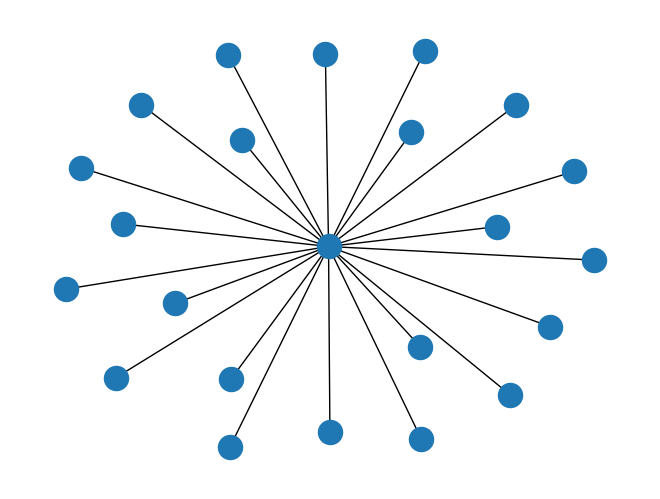

In [23]:
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph
import networkx as nx
import matplotlib.pyplot as plt

ug8 = rdflib_to_networkx_graph(g8)
nx.draw(ug8)

We can also use the ipysigma library, for displaing an interactive graph (but its work only in an interactive jupyter session)

In [26]:
from ipysigma import Sigma
Sigma(ug8)

Sigma(nx.Graph with 23 nodes and 22 edges)

## 2.2 Querying for the list of statements for a given project

A view of the graph's depth at the level of a project description.

In [ ]:
g6 = Graph()
g6.bind("fg_wd", FG_WD)
g6.bind("fg_wikibase", FG_WIKIBASE)
# define query for statements of a choosen project
qres = g6.query(
   """
SELECT ?project ?wd_labell ?ps_ ?ps_labell ?wdpq ?wdpq_labell ?pq_ ?pq_labell
WHERE {
    SERVICE <https://database.factgrid.de/sparql> {
  VALUES (?project) {(fg_wd:Q467586)}

  ?project ?p ?statement .
  ?statement ?ps ?ps_ .
  OPTIONAL { ?ps_ rdfs:label ?ps_labell.
  FILTER(lang(?ps_labell) IN ('en'))}
  ?wd fg_wikibase:claim ?p .
  ?wd fg_wikibase:statementProperty ?ps .
  OPTIONAL {?wd rdfs:label ?wd_labell.
  FILTER(lang(?wd_labell) IN ('en'))}

  OPTIONAL {
  ?statement ?pq ?pq_ .
  ?wdpq fg_wikibase:qualifier ?pq .
  ?wdpq rdfs:label ?wdpq_labell.
  FILTER(lang(?wdpq_labell) IN ('en'))
  ?pq_ rdfs:label ?pq_labell.
  FILTER(lang(?pq_labell) IN ('en'))
  }
  }
}
 ORDER BY ?wd ?ps_
   """
)

In [ ]:
sparql_results_to_df(qres)

## Draw resulting graph

## TODO: network of information / agents surrounding a project

## 2.3 Querying for topics of FactGrid projects

In [ ]:
g7 = Graph()
g7.bind("fg_wd", FG_WD)
g7.bind("fg_wdt", FG_WDT)
# define query for projects
qres = g7.query(
   """
SELECT ?topic_labell ?project_labell ?date
WHERE {
    SERVICE <https://database.factgrid.de/sparql> {
        ?project fg_wdt:P2 fg_wd:Q11295 .
	?project fg_wdt:P49 ?date .
	?project fg_wdt:P243 ?topic .
      	?project rdfs:label ?project_labell.
      	FILTER(lang(?project_labell) IN ('en'))
      	?topic rdfs:label ?topic_labell.
      	FILTER(lang(?topic_labell) IN ('en'))
   }
}
ORDER BY ?topic_labell
   """
)

In [ ]:
sparql_results_to_df(qres)

## Draw timeline

# 3.0 Collecting sub-graph of a given project

## build query

In [ ]:
g9 = Graph()
g9.bind("fg_wd", FG_WD)
g9.bind("fg_wikibase", FG_WIKIBASE)
# define query for projects
qres = g9.query(
   """
SELECT ?s ?wd ?o
WHERE {
  SERVICE <https://database.factgrid.de/sparql> {
    {
	  BIND (fg_wd:Q467586 as ?s)
	  ?s ?p ?o.
	  ?wd fg_wikibase:directClaim ?p.
	}
	UNION
    {
	  BIND (fg_wd:Q467586 as ?o)
	  ?s ?p ?o.
	  ?wd fg_wikibase:directClaim ?p .
	}
}}
"""
)

# Due of rdflib's limitation
import rdflib
for row in qres:
    if type(row[2]) == rdflib.term.URIRef:
        g9.add(row)

## draw a network ?

In [ ]:
ug9 = rdflib_to_networkx_graph(g9)
Sigma(ug9)

## Store rdf triples

In [ ]:
# The graph g9 is write in "my_graph.rdf" file
g9.serialize(destination="my_graph.rdf", format="xml")

# Creating a knowledge graph 

## Create a couple of triples with Python and `rdflib`

In [ ]:
from rdflib import Graph, Literal, RDF, URIRef
# rdflib knows about quite a few popular namespaces, like W3C ontologies, schema.org etc.
from rdflib.namespace import FOAF , XSD

# Create a Graph
g = Graph()

# Create an RDF URI node to use as the subject for multiple triples
donna = URIRef("http://example.org/donna")

# Add triples using store's add() method.
g.add((donna, RDF.type, FOAF.Person))
g.add((donna, FOAF.nick, Literal("donna", lang="en")))
g.add((donna, FOAF.name, Literal("Donna Fales")))
g.add((donna, FOAF.mbox, URIRef("mailto:donna@example.org")))

# Add another person
ed = URIRef("http://example.org/edward")

# Add triples using store's add() method.
g.add((ed, RDF.type, FOAF.Person))
g.add((ed, FOAF.nick, Literal("ed", datatype=XSD.string)))
g.add((ed, FOAF.name, Literal("Edward Scissorhands")))
g.add((ed, FOAF.mbox, Literal("e.scissorhands@example.org", datatype=XSD.anyURI)))

# Bind the FOAF namespace to a prefix for more readable output
g.bind("foaf", FOAF)

## Representations of the knowledge graph

### In the `n3` serialization format

In [ ]:
# print all the data in the Notation3 format
print(g.serialize(format='n3'))

### As a network graph

In [ ]:
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph
import networkx as nx
import matplotlib.pyplot as plt

ug = rdflib_to_networkx_graph(g)
nx.draw(ug)

# Session information

In [ ]:
import session_info
session_info.show()

# APPENDICES - Figures with `plotly.graph_objects`

In [ ]:
import plotly.graph_objects as go
import numpy as np

# Create figure
fig = go.Figure()

# Add traces, one for each slider step
for step in np.arange(0, 5, 0.1):
    fig.add_trace(
        go.Scatter(
            visible=False,
            line=dict(color="#00CED1", width=6),
            name="𝜈 = " + str(step),
            x=np.arange(0, 10, 0.01),
            y=np.sin(step * np.arange(0, 10, 0.01))))

# Make 10th trace visible
fig.data[10].visible = True

# Create and add slider
steps = []
for i in range(len(fig.data)):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},
              {"title": "Slider switched to step: " + str(i)}],  # layout attribute
    )
    step["args"][0]["visible"][i] = True  # Toggle i'th trace to "visible"
    steps.append(step)

sliders = [dict(
    active=10,
    currentvalue={"prefix": "Frequency: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders
)

fig.show()